In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import re

In [7]:
logs_dqn = '/home/yarl/Desktop/git/Urban/back/res/logs/DQN/details'
logs_ppo = '/home/yarl/Desktop/git/Urban/back/res/logs/PPO/details'

a = pd.read_csv('/home/yarl/Desktop/git/Urban/back/res/logs/DQN/model_parallel1.csv')
b = pd.read_csv('/home/yarl/Desktop/git/Urban/back/res/logs/DQN/model_parallel2.csv')
c = pd.read_csv('/home/yarl/Desktop/git/Urban/back/res/logs/DQN/model_parallel3.csv')

rewards = pd.concat([a, b, c])

In [10]:
rewards_dqn = rewards
rewards_ppo = pd.read_csv('/home/yarl/Desktop/git/Urban/back/res/logs/PPO/training_rewards_ep1000.csv')
rewards_ppo

,reward
0,-5.156528e+06
1,-2.531016e+06
2,-2.780076e+06
3,-2.278987e+06
4,-2.267056e+06
...,...
995,-6.529453e+05
996,-6.604108e+05
997,-8.255395e+05
998,-9.515039e+05


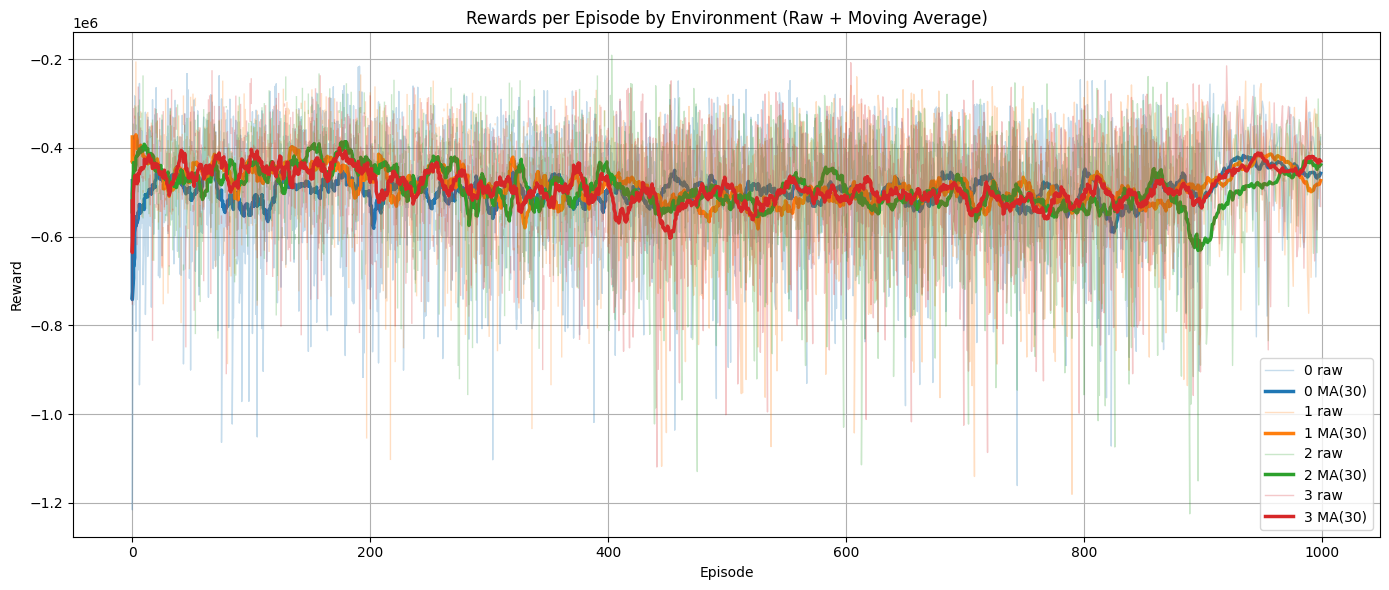

In [35]:
data = rewards_dqn.copy().reset_index().rename(columns={"index": "episode"})

df_long = data.melt(id_vars="episode", var_name="environment", value_name="reward")

df_long = df_long.sort_values(["episode", "environment"]).reset_index(drop=True)

colors = plt.cm.tab10.colors
plt.figure(figsize=(14, 6))

for i, env in enumerate(df_long["environment"].unique()):
    df_env = df_long[df_long["environment"] == env]
    x = df_env["episode"]
    y = df_env["reward"]
    color = colors[i % len(colors)]

    plt.plot(x, y, color=color, alpha=0.25, linewidth=1, label=f"{env} raw")

    y_ma = y.rolling(window=30, min_periods=1).mean()
    plt.plot(x, y_ma, color=color, linewidth=2.5, label=f"{env} MA(30)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per Episode by Environment (Raw + Moving Average)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


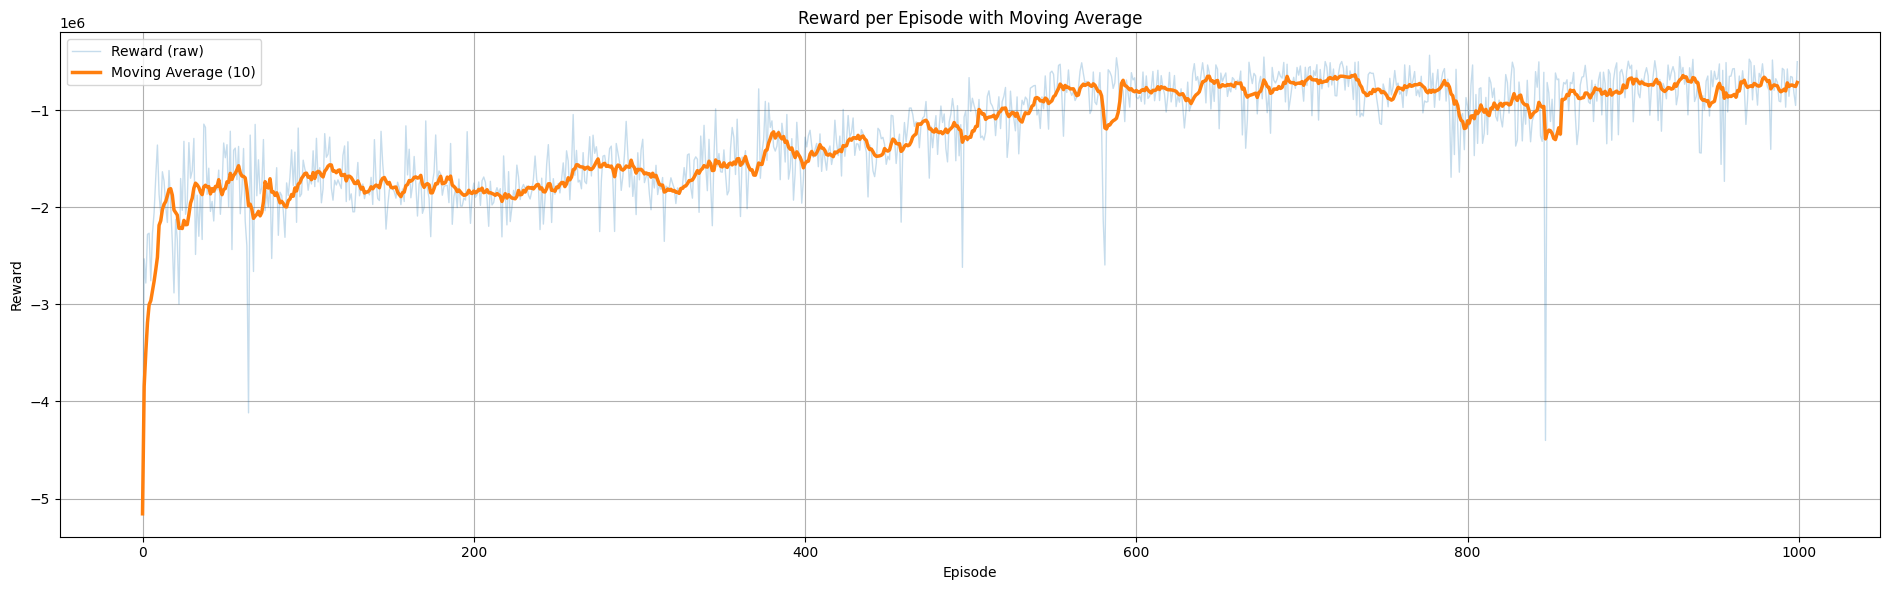

In [13]:
window = 10
rewards_ppo["reward_ma"] = rewards_ppo["reward"].rolling(window=window, min_periods=1).mean()

plt.figure(figsize=(19, 6))

plt.plot(
    rewards_ppo.index,
    rewards_ppo["reward"],
    alpha=0.25,
    linewidth=1,
    label="Reward (raw)"
)

plt.plot(
    rewards_ppo.index,
    rewards_ppo["reward_ma"],
    linewidth=2.5,
    label=f"Moving Average ({window})"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Reward per Episode with Moving Average")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
log_fold = "/home/yarl/Desktop/git/Urban/back/res/logs/PPO/details"
logs = glob.glob(f"{log_fold}/ep*.log")

records = []

for file in logs:
    m = re.search(r"ep(\d+)\.log", file)
    if not m:
        continue

    episode = int(m.group(1))
    record = {"episode": episode}

    with open(file, "r") as f:
        content = f.read()

    patterns = {
        "duration_s": r"Duration:\s*([\d.]+)s",
        "traci_duration_s": r"TraCI-Duration:\s*([\d.]+)s",
        "real_time_factor": r"Real time factor:\s*([\d.]+)",
        "UPS": r"UPS:\s*([\d.]+)"
    }

    for key, pattern in patterns.items():
        m = re.search(pattern, content)
        if m:
            record[key] = float(m.group(1))

    m = re.search(
        r"Inserted:\s*(\d+).*Running:\s*(\d+).*Waiting:\s*(\d+).*Teleports:\s*(\d+)",
        content
    )
    if m:
        record["inserted"] = int(m.group(1))
        record["running"] = int(m.group(2))
        record["waiting"] = int(m.group(3))
        record["teleports"] = int(m.group(4))

    m = re.search(
        r"Emergency Stops:\s*(\d+).*Emergency Braking:\s*(\d+)",
        content
    )
    if m:
        record["emergency_stops"] = int(m.group(1))
        record["emergency_braking"] = int(m.group(2))

    m = re.search(
        r"Statistics \(avg of [\d]+\):\s*([\s\S]+?)DijkstraRouter",
        content
    )
    if m:
        stats_lines = m.group(1).strip().split("\n")
        for line in stats_lines:
            if ":" not in line:
                continue

            k, v = line.split(":", 1)
            k = k.strip()
            v = v.strip()

            try:
                record[k] = float(v)
            except ValueError:
                record[k] = v

    records.append(record)

ppo_logs = pd.DataFrame(records)


In [24]:
ppo_logs

,episode,duration_s,traci_duration_s,real_time_factor,UPS,RouteLength,Speed,Duration,WaitingTime,TimeLoss,DepartDelay
0,1,80.57,56.54,12.4120,15762.520635,2597.73,11.00,266.73,69.71,141.21,13.84
1,2,77.08,53.11,12.9740,15376.324974,2734.01,11.03,286.59,84.07,155.92,13.54
2,3,78.01,53.62,12.8185,15863.354356,2634.41,10.94,275.10,77.31,149.15,13.23
3,4,77.66,53.51,12.8766,16047.257275,2720.75,11.25,278.22,77.98,149.38,13.88
4,5,94.46,65.42,10.5863,13183.290635,2686.68,11.26,278.02,79.18,149.63,10.25
...,...,...,...,...,...,...,...,...,...,...,...
996,997,81.12,56.40,12.3276,13837.226790,2737.86,11.43,262.50,58.84,130.95,7.63
997,998,84.73,58.00,11.8016,13464.866523,2732.84,11.14,276.14,67.20,144.03,8.68
998,999,86.80,59.46,11.5203,12912.998399,2739.06,11.34,263.33,58.10,130.85,8.09
999,1000,87.44,59.83,11.4367,12778.826140,2726.25,11.21,267.95,60.90,135.67,9.40


In [27]:
ppo_logs = ppo_logs.sort_values("episode").reset_index(drop=True)

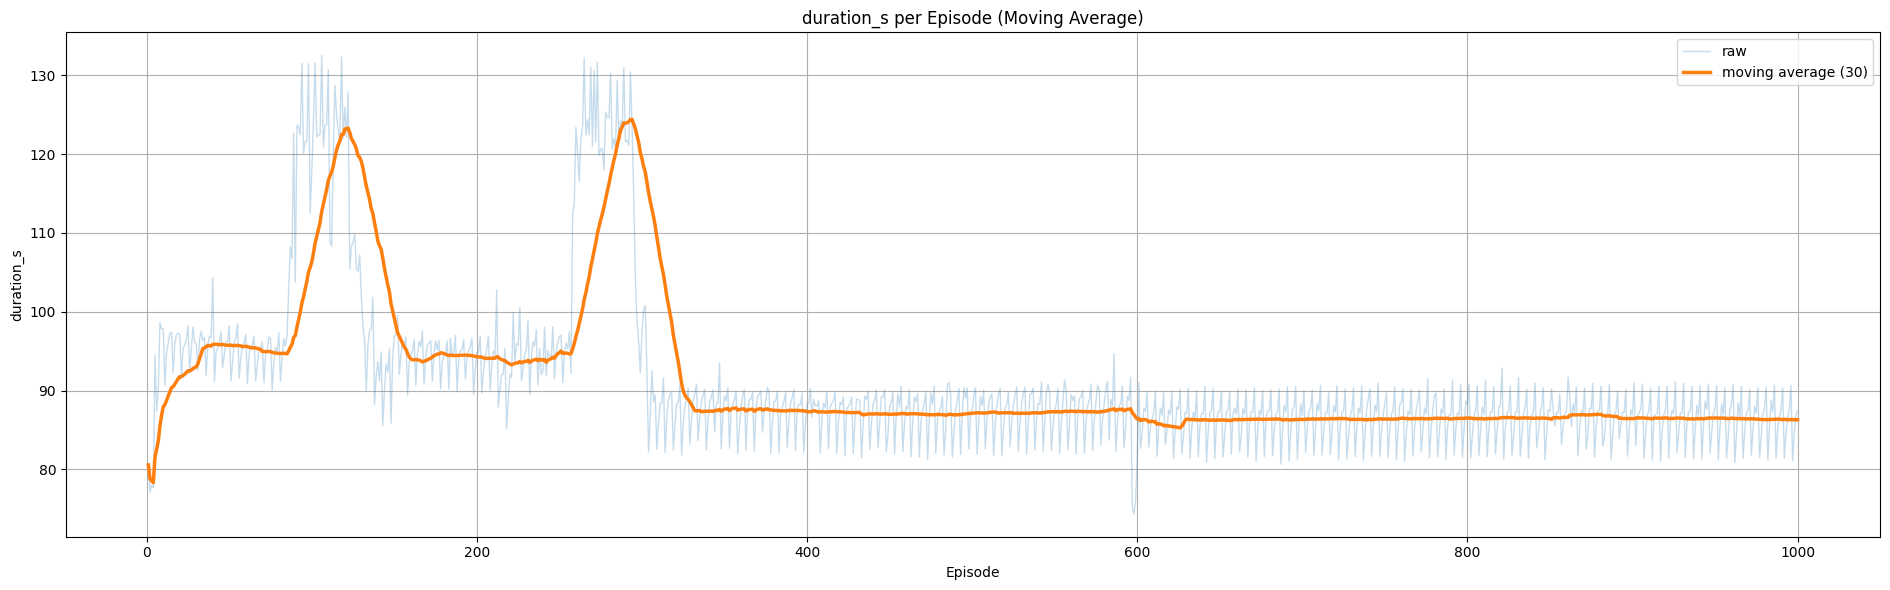

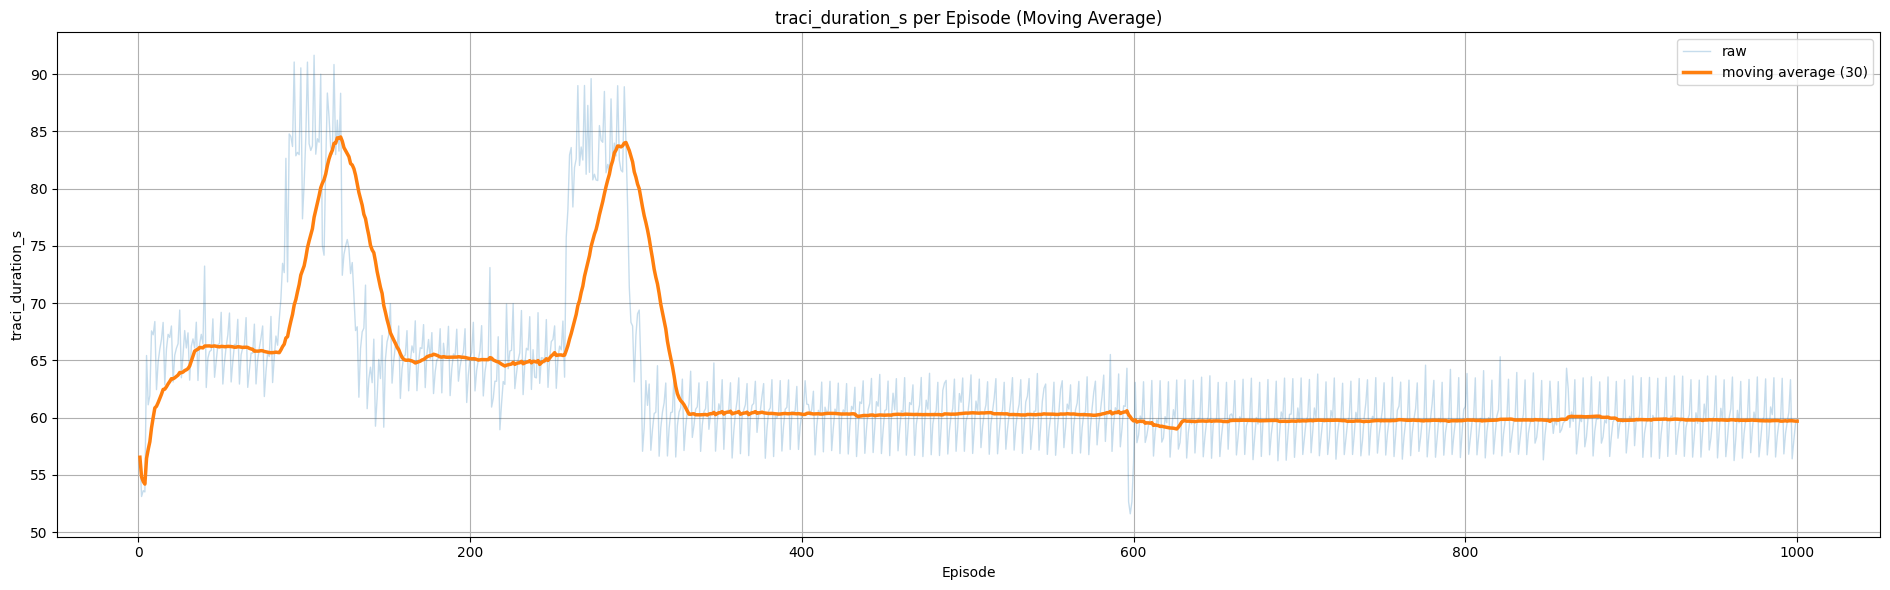

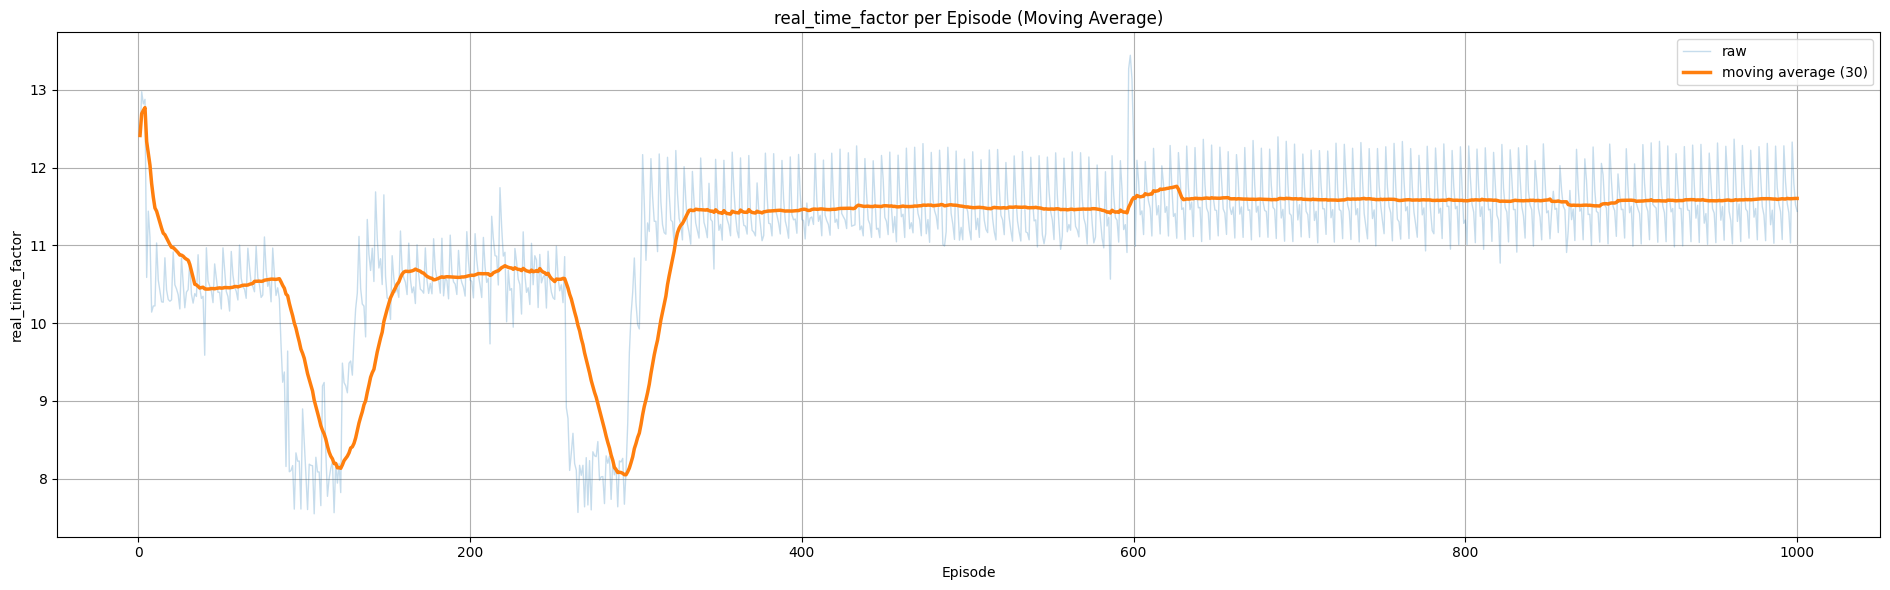

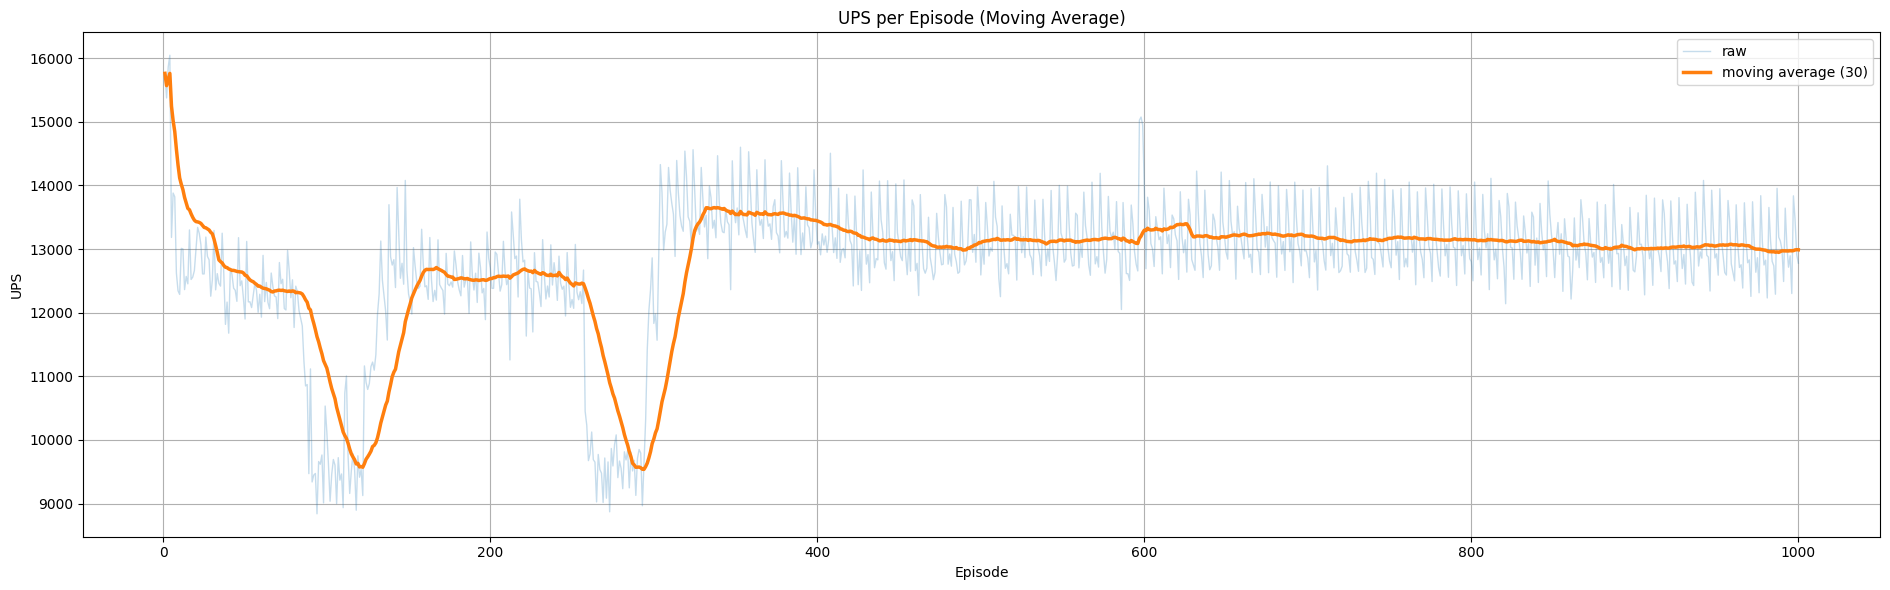

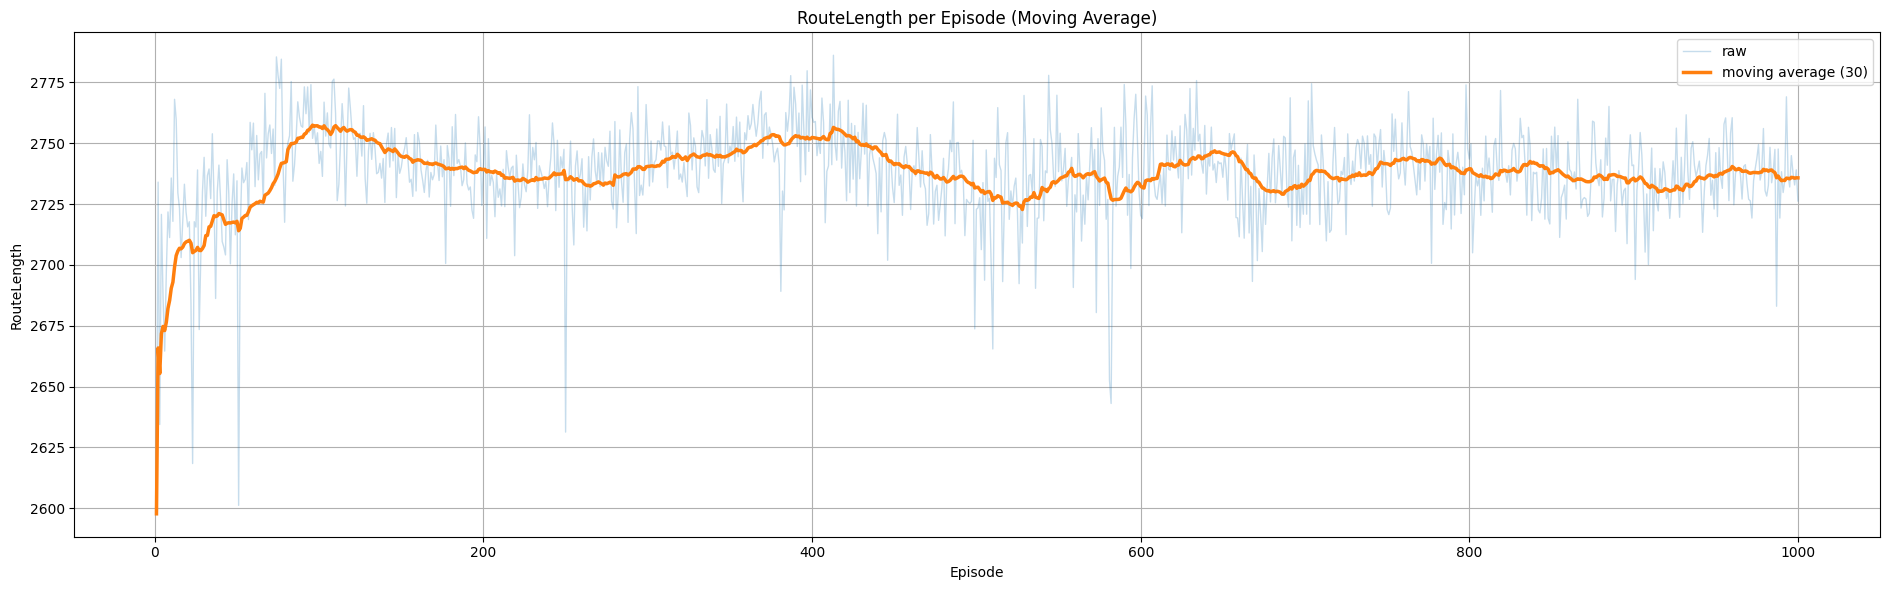

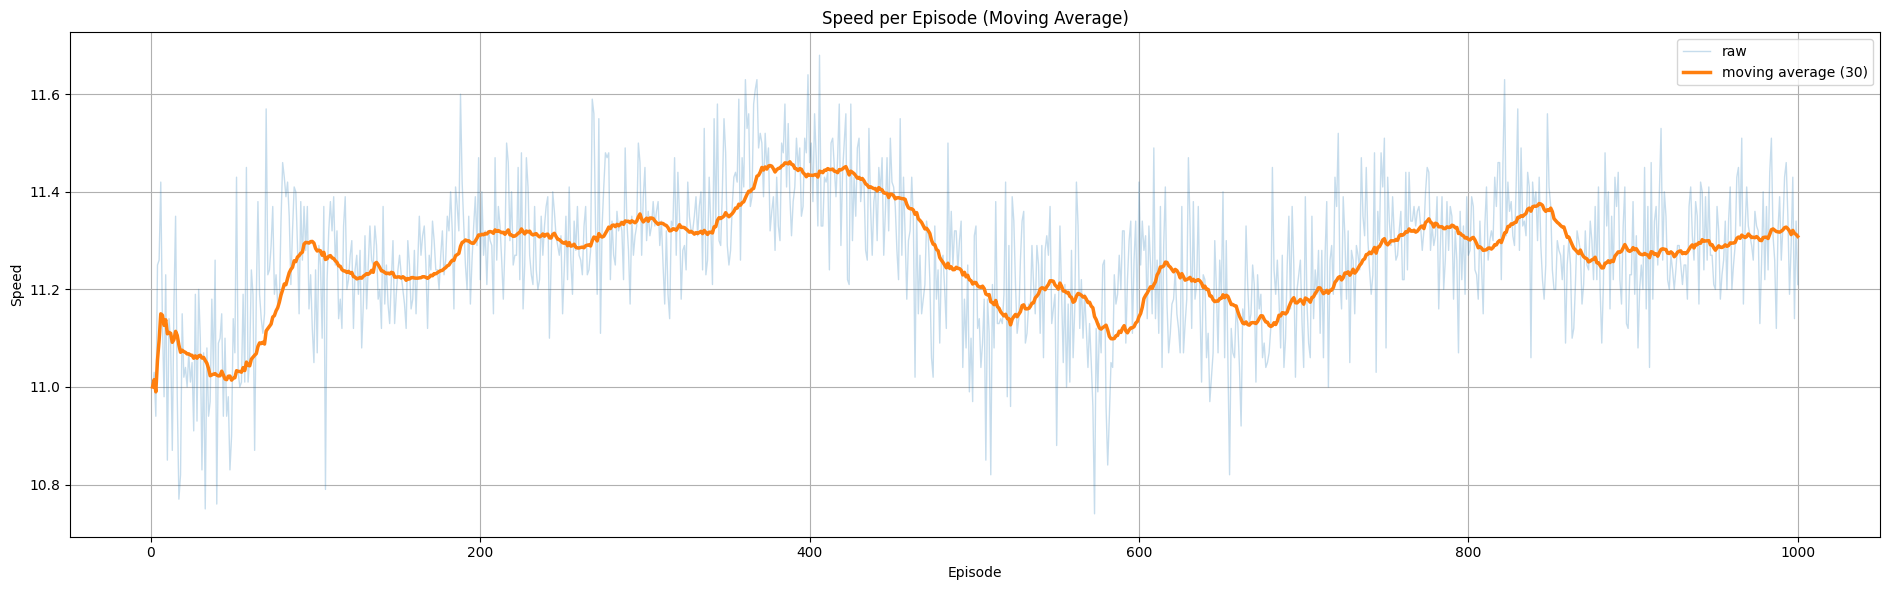

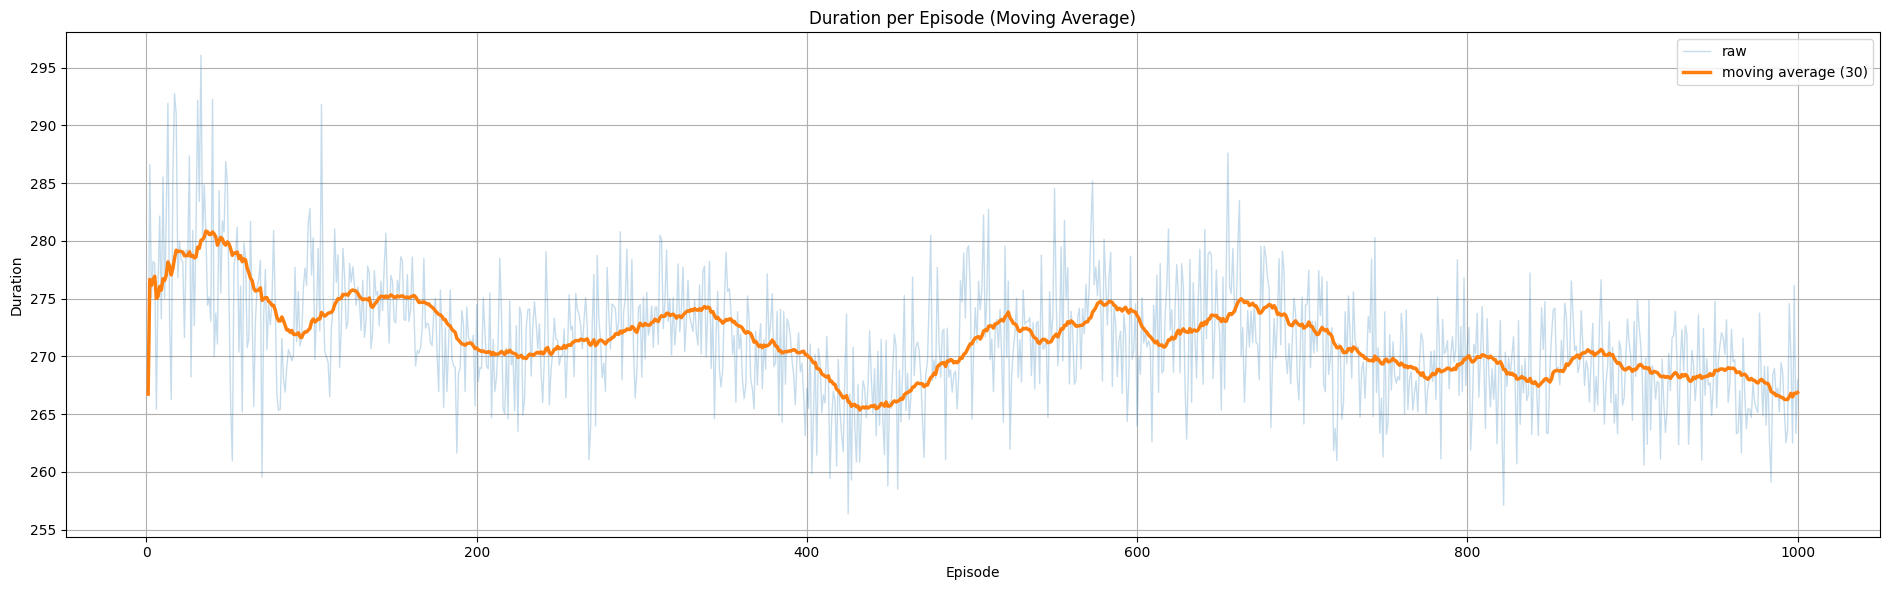

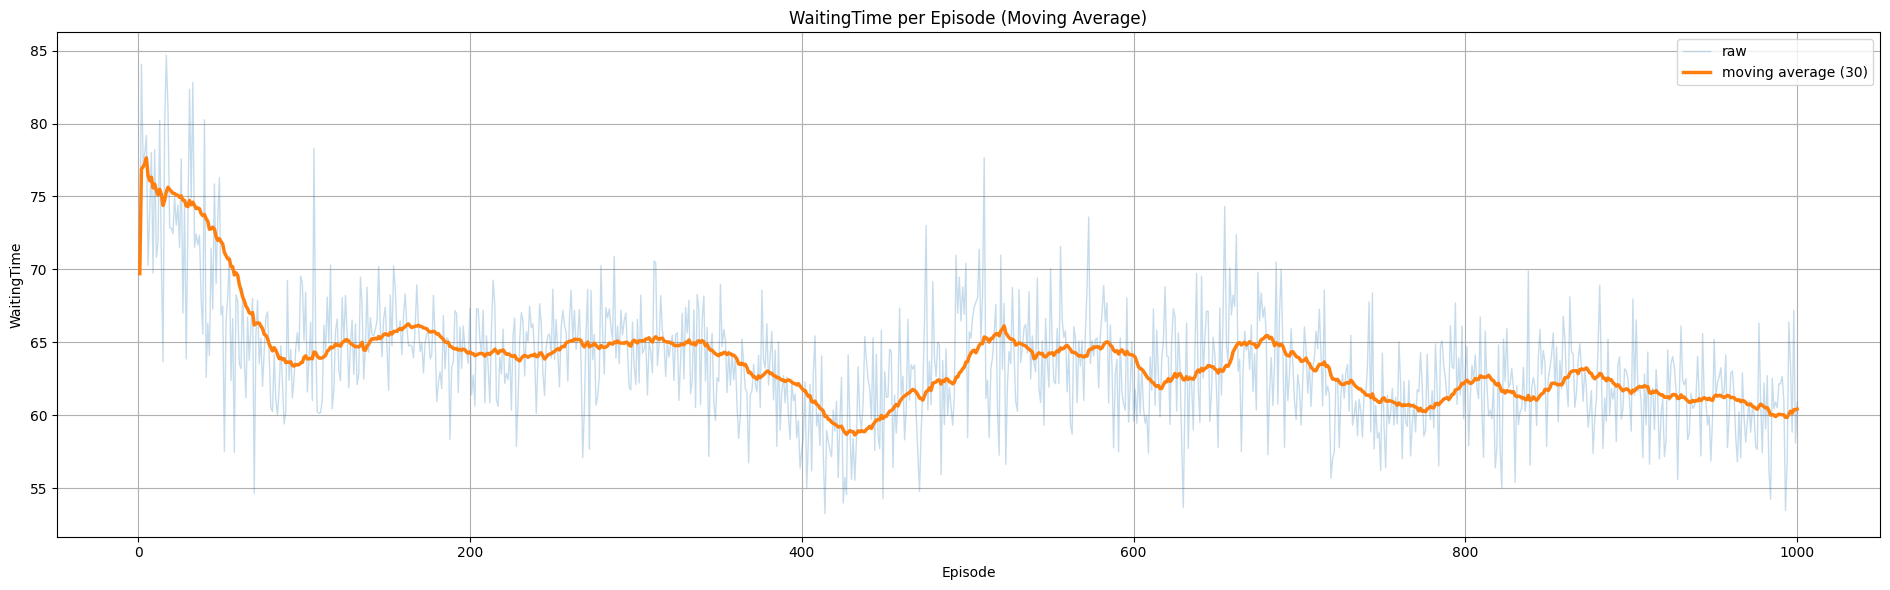

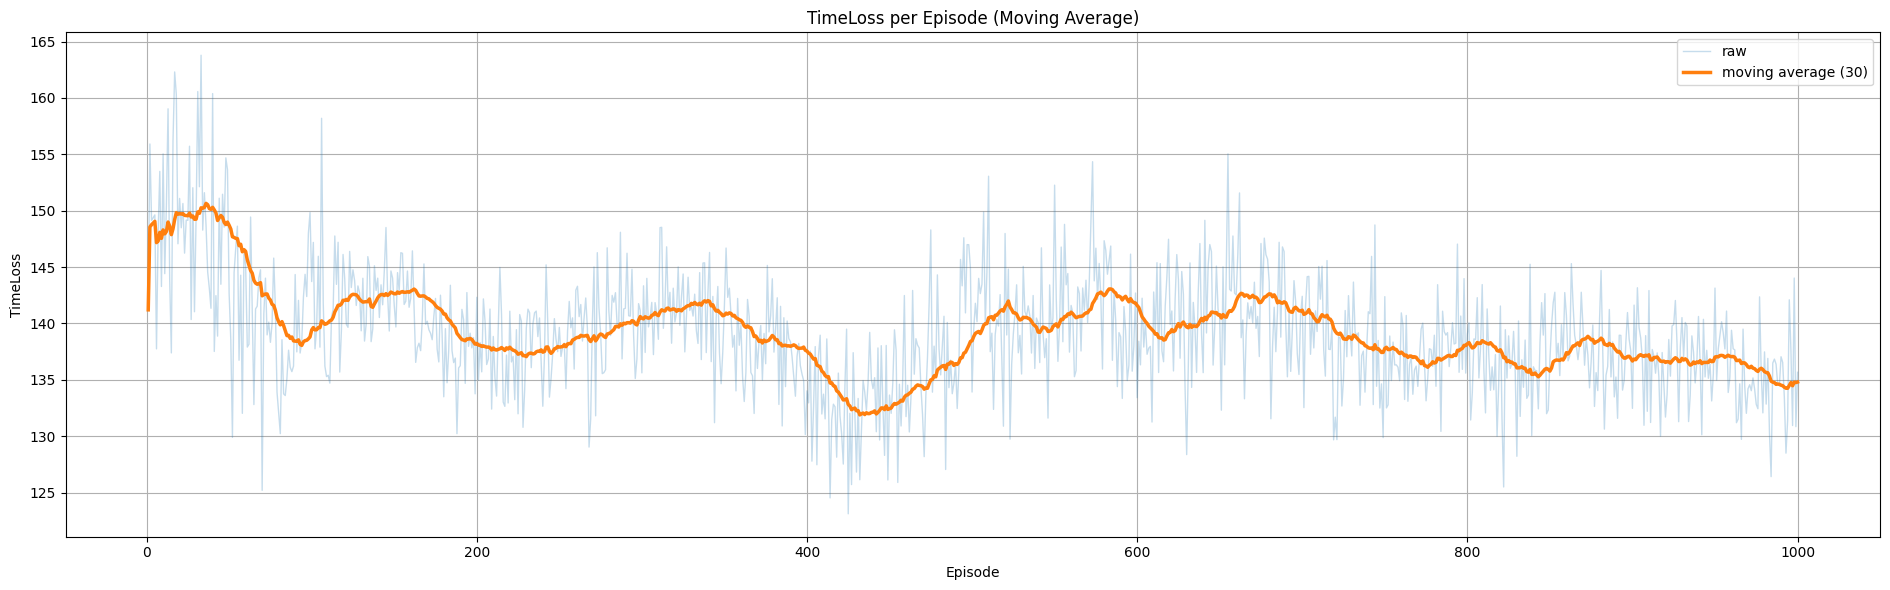

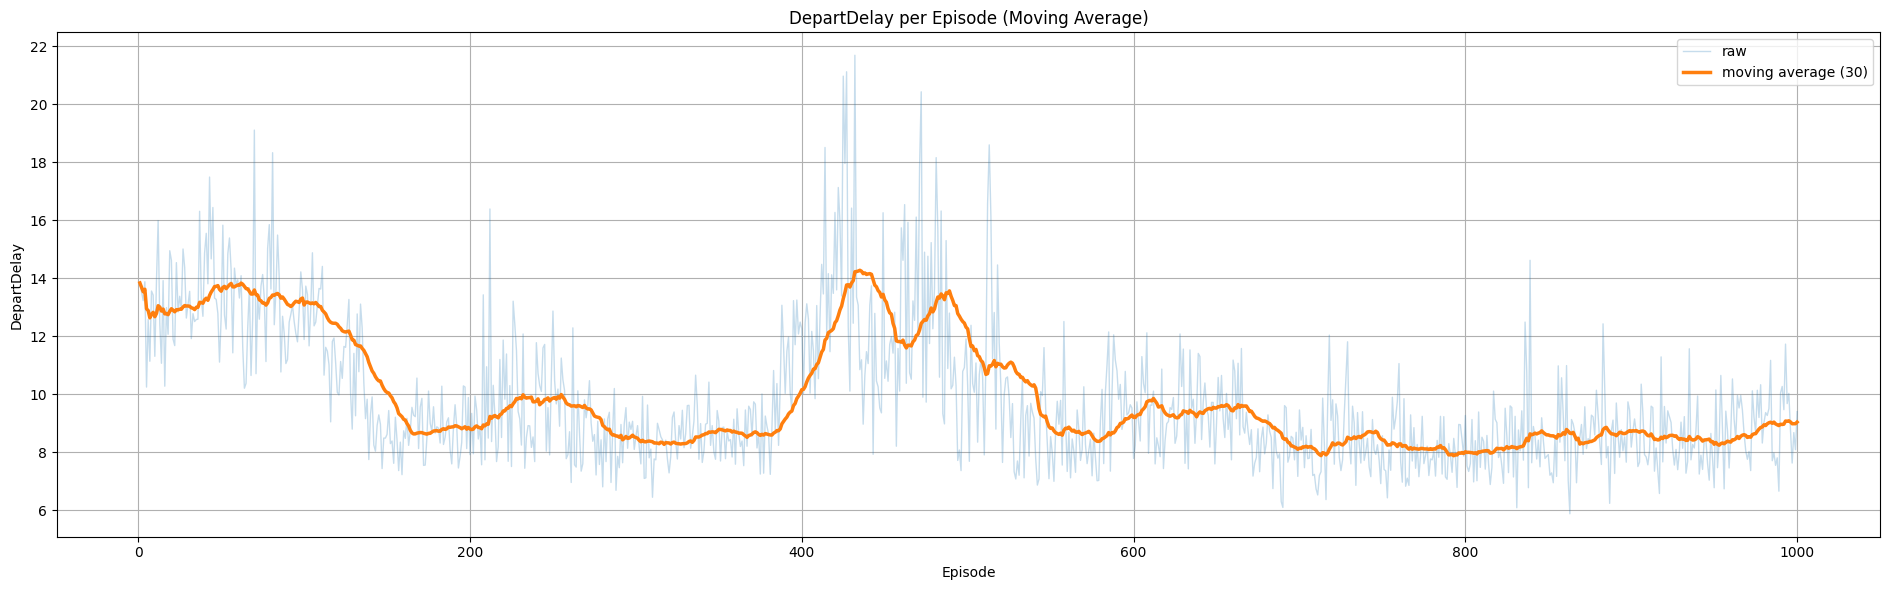

In [28]:
x = ppo_logs["episode"]

cols = [col for col in ppo_logs.columns if col != "episode"]

for col in cols:
    plt.figure(figsize=(19, 6))

    y = ppo_logs[col]

    plt.plot(
        x,
        y,
        alpha=0.25,
        linewidth=1,
        label="raw"
    )

    y_ma = y.rolling(window=30, min_periods=1).mean()
    plt.plot(
        x,
        y_ma,
        linewidth=2.5,
        label="moving average (30)"
    )

    plt.xlabel("Episode")
    plt.ylabel(col)
    plt.title(f"{col} per Episode (Moving Average)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [30]:
rewards_dqn

,0,1,2,3
0,-474170.302320,-375667.352910,-544113.987764,-520048.257836
1,-547848.566921,-392179.796459,-347115.985552,-417802.062360
2,-521024.665442,-332712.144215,-477609.332637,-329126.872490
3,-348303.461373,-481870.776334,-357757.081335,-451053.580885
4,-444674.560130,-480703.468293,-384538.763059,-617684.652276
...,...,...,...,...
395,-627773.978762,NaN,NaN,NaN
396,-417054.949891,NaN,NaN,NaN
397,-384757.961908,NaN,NaN,NaN
398,-457244.786925,NaN,NaN,NaN


In [36]:
log_fold = "/home/yarl/Desktop/git/Urban/back/res/logs/DQN/details"
logs = glob.glob(f"{log_fold}/env_*_ep*.log") 

records = []

for file in logs:
    m = re.search(r"env_(\d+)_ep(\d+)\.log", file)
    if not m:
        continue

    environment = f"env_{m.group(1)}"
    episode = int(m.group(2))
    record = {"environment": environment, "episode": episode}

    # read log content
    with open(file, "r") as f:
        content = f.read()

    # performance metrics
    patterns = {
        "duration_s": r"Duration:\s*([\d.]+)s",
        "traci_duration_s": r"TraCI-Duration:\s*([\d.]+)s",
        "real_time_factor": r"Real time factor:\s*([\d.]+)",
        "UPS": r"UPS:\s*([\d.]+)"
    }

    for key, pattern in patterns.items():
        m = re.search(pattern, content)
        if m:
            record[key] = float(m.group(1))

    # Vehicles
    for key, pattern in [("inserted", r"Inserted:\s*(\d+)"),
                         ("running", r"Running:\s*(\d+)"),
                         ("waiting", r"Waiting:\s*(\d+)"),
                         ("teleports", r"Teleports:\s*(\d+)"),
                         ("emergency_stops", r"Emergency Stops:\s*(\d+)"),
                         ("emergency_braking", r"Emergency Braking:\s*(\d+)")]:
        m = re.search(pattern, content)
        if m:
            record[key] = int(m.group(1))

    # Statistics
    m = re.search(r"Statistics \(avg of \d+\):\s*([\s\S]+?)(?:DijkstraRouter|$)", content)
    if m:
        for line in m.group(1).splitlines():
            if ":" not in line:
                continue
            k, v = line.split(":", 1)
            k = k.strip()
            v = v.strip()
            try:
                record[k] = float(v)
            except ValueError:
                record[k] = v

    records.append(record)

# create DataFrame
dqn_logs = pd.DataFrame(records)
dqn_logs = dqn_logs.sort_values(["environment", "episode"]).reset_index(drop=True)


In [37]:
dqn_logs

,environment,episode,duration_s,traci_duration_s,real_time_factor,UPS,inserted,running,waiting,teleports,emergency_stops,emergency_braking,RouteLength,Speed,Duration,WaitingTime,TimeLoss,DepartDelay
0,env_0,0,2.12,0.00,0.00000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00
1,env_0,1,176.77,141.25,5.65704,6751.582556,3938.0,1829.0,675.0,48.0,396.0,713.0,2712.60,10.74,291.06,83.61,159.03,12.51
2,env_0,2,177.32,141.89,5.63952,6631.423415,3984.0,1786.0,629.0,42.0,399.0,708.0,2770.02,10.98,289.00,78.47,156.01,10.77
3,env_0,3,178.11,142.91,5.61441,6402.356931,3971.0,1738.0,642.0,45.0,379.0,714.0,2744.79,11.17,274.62,68.38,143.53,11.89
4,env_0,4,177.92,142.12,5.62054,6809.615612,4009.0,1945.0,604.0,23.0,382.0,733.0,2649.06,10.85,285.57,84.76,158.47,10.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8155,env_3,1995,204.78,163.59,4.88327,5667.737730,3965.0,1818.0,648.0,50.0,369.0,679.0,2748.55,11.23,274.14,68.31,142.83,13.34
8156,env_3,1996,204.63,163.20,4.88682,5834.713046,3975.0,1830.0,638.0,46.0,422.0,750.0,2771.96,11.32,277.78,69.12,144.82,13.07
8157,env_3,1997,204.35,163.16,4.89368,5591.602437,3957.0,1709.0,656.0,38.0,420.0,728.0,2778.25,11.20,279.86,69.81,146.73,11.65
8158,env_3,1998,204.77,163.17,4.88343,5768.627853,3940.0,1769.0,673.0,62.0,397.0,697.0,2770.44,11.06,285.42,75.60,152.78,10.87


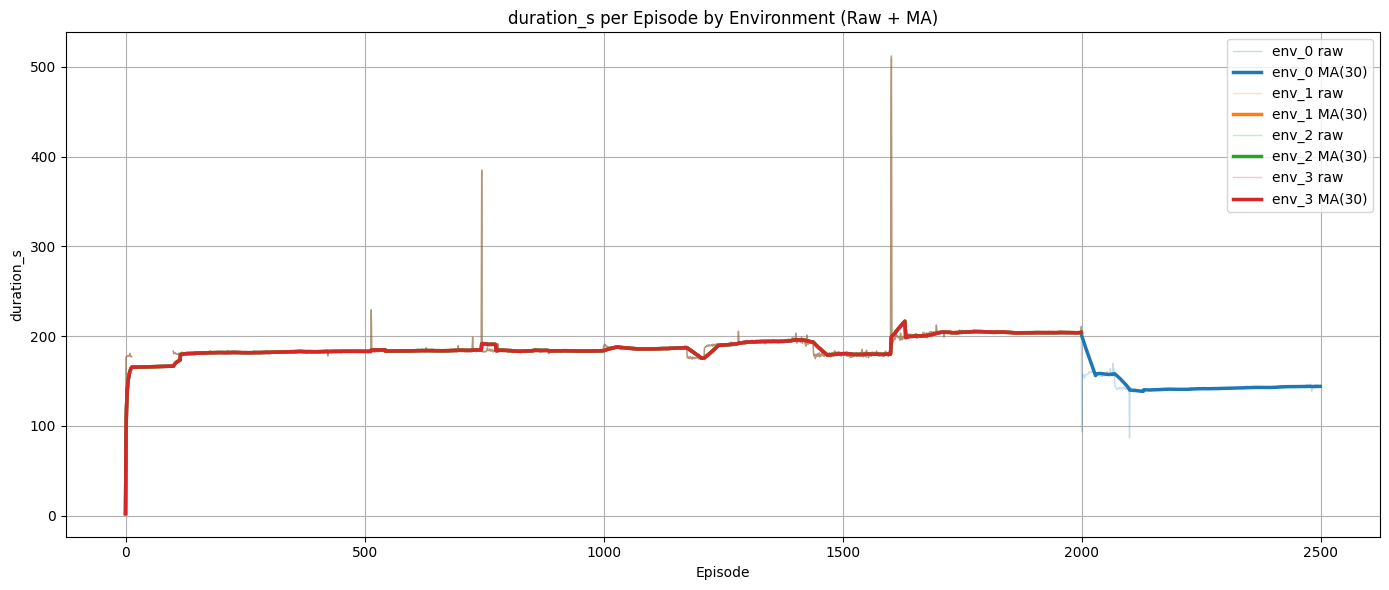

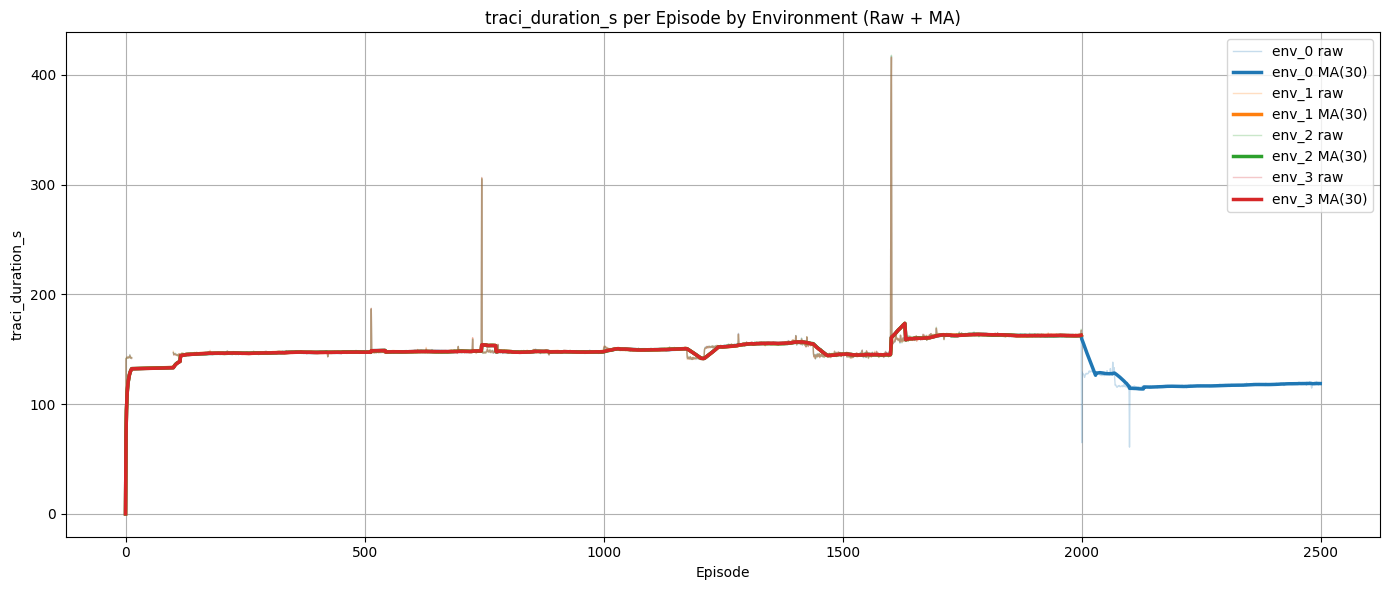

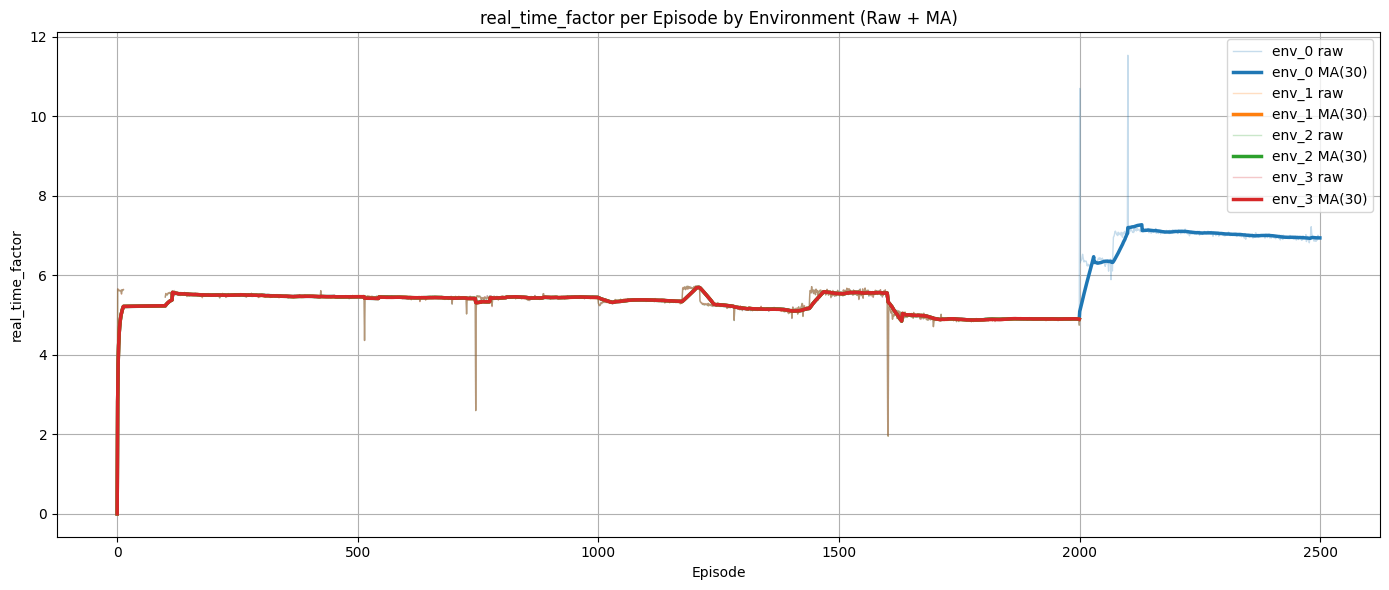

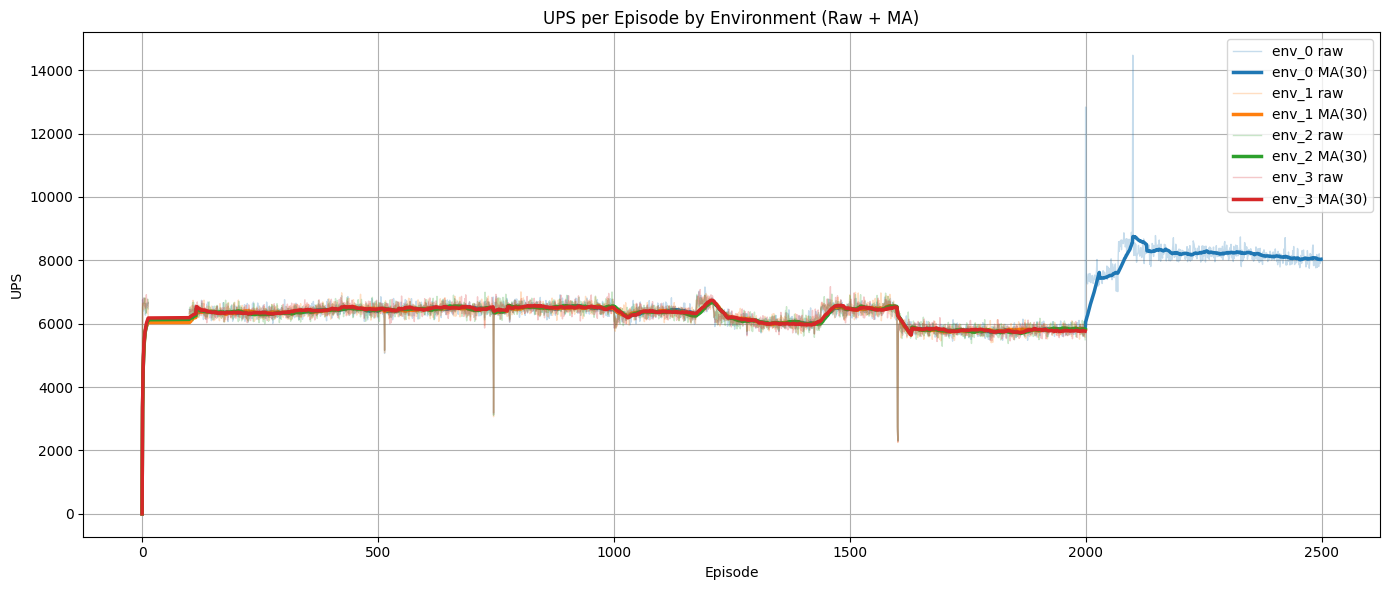

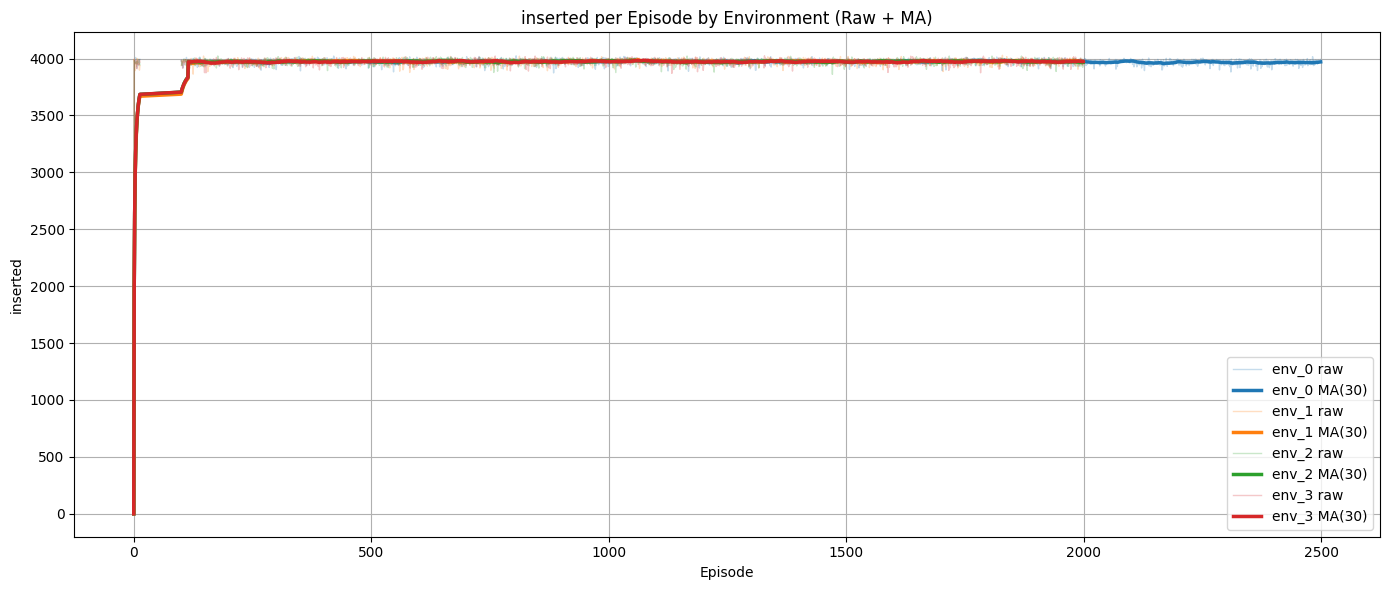

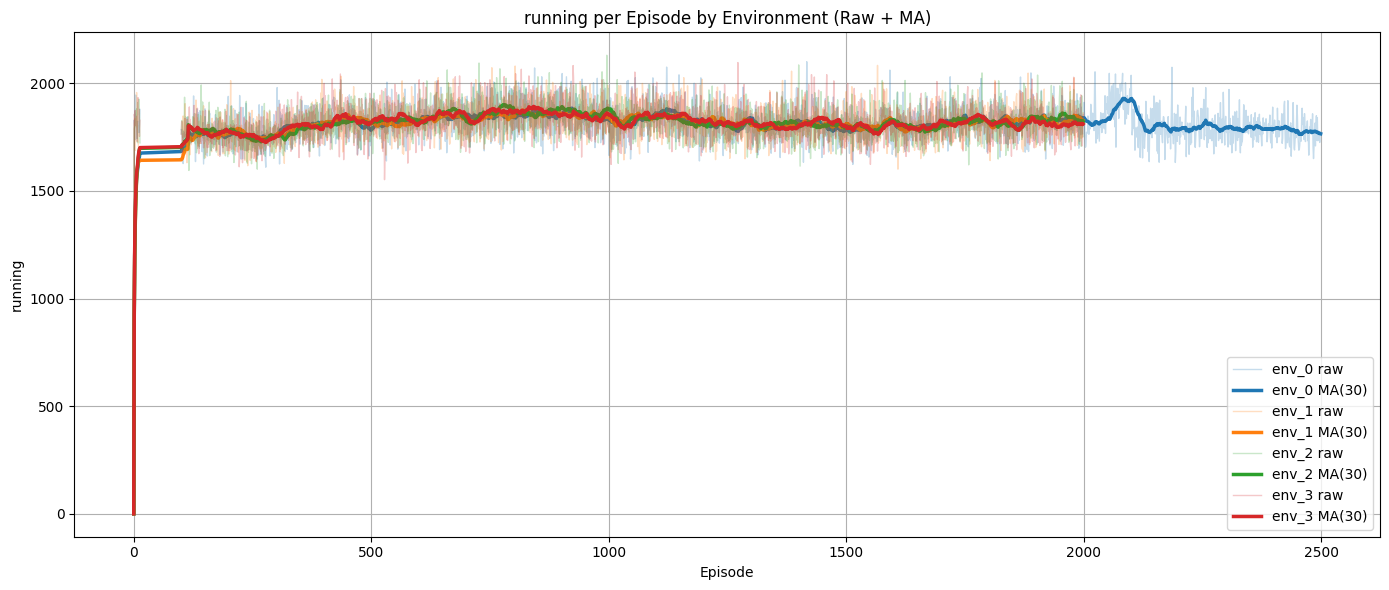

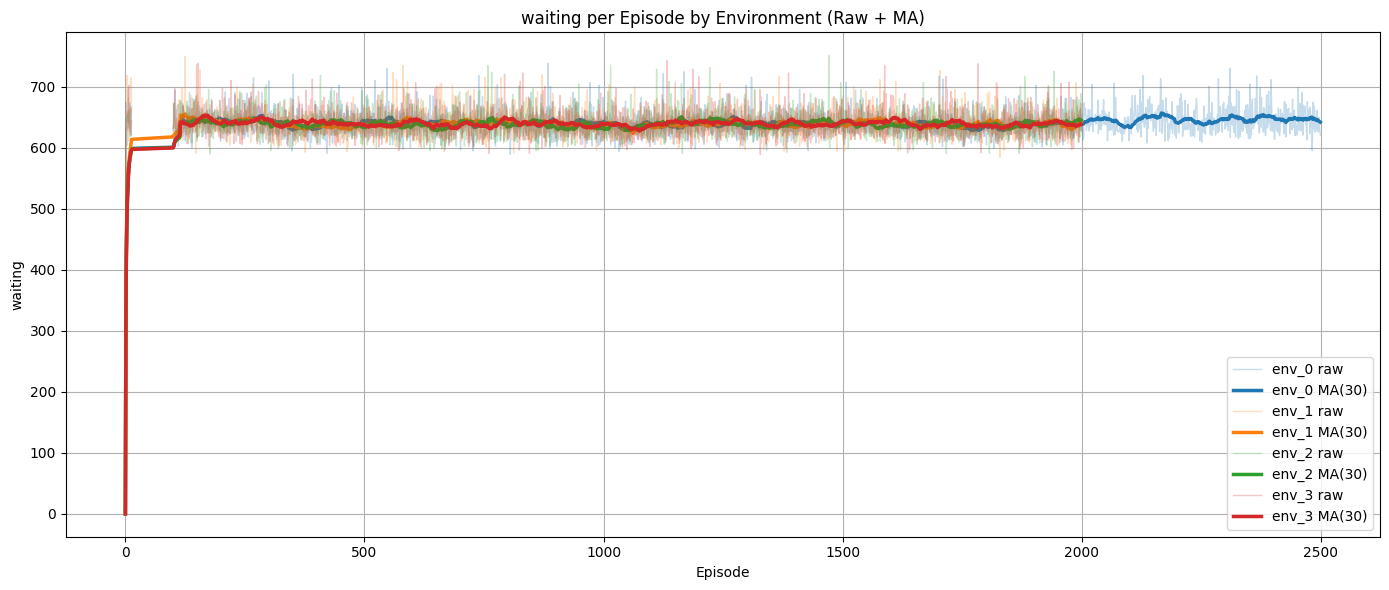

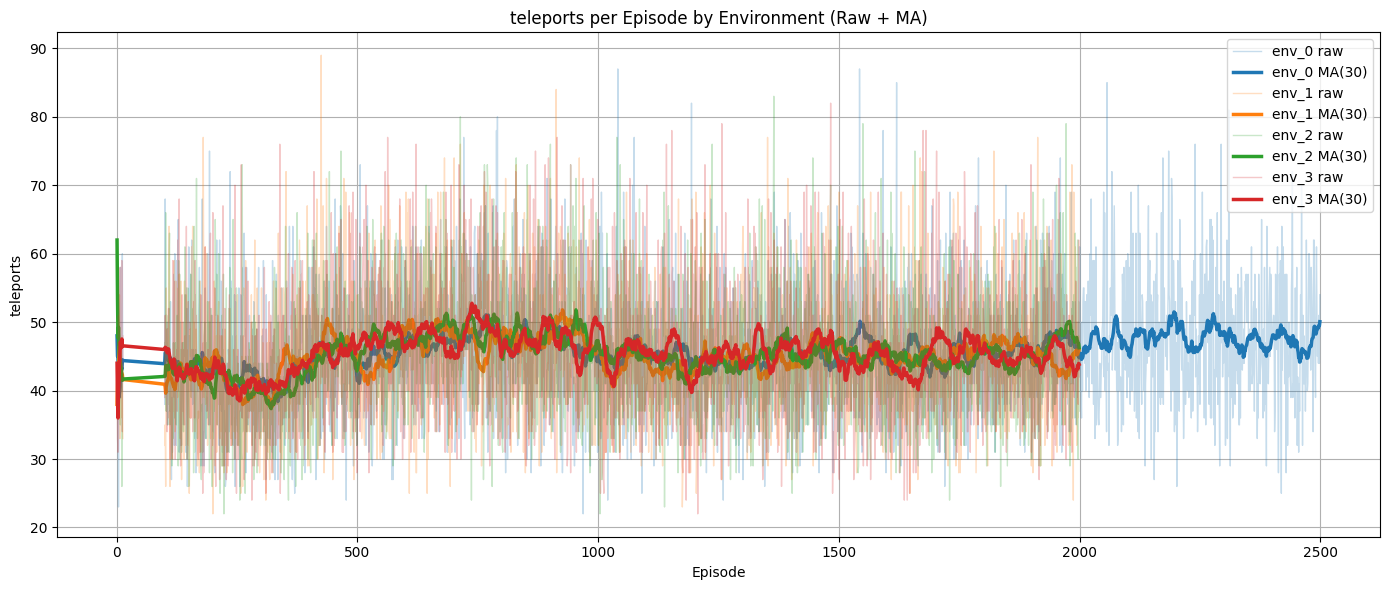

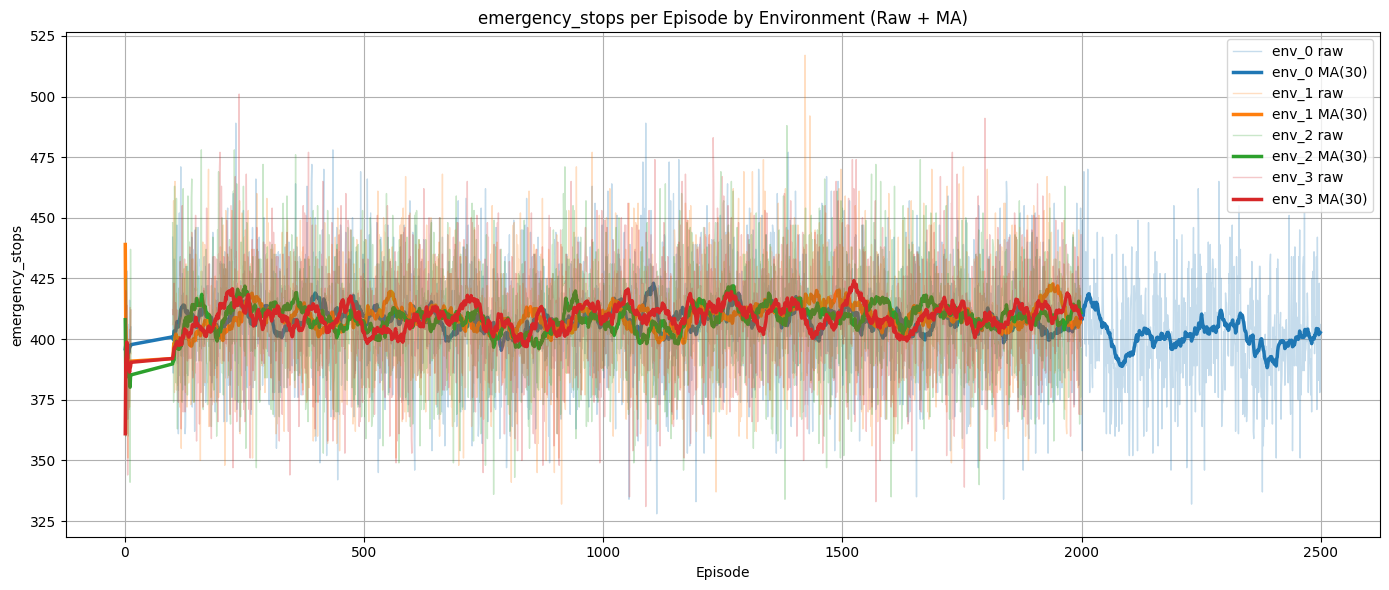

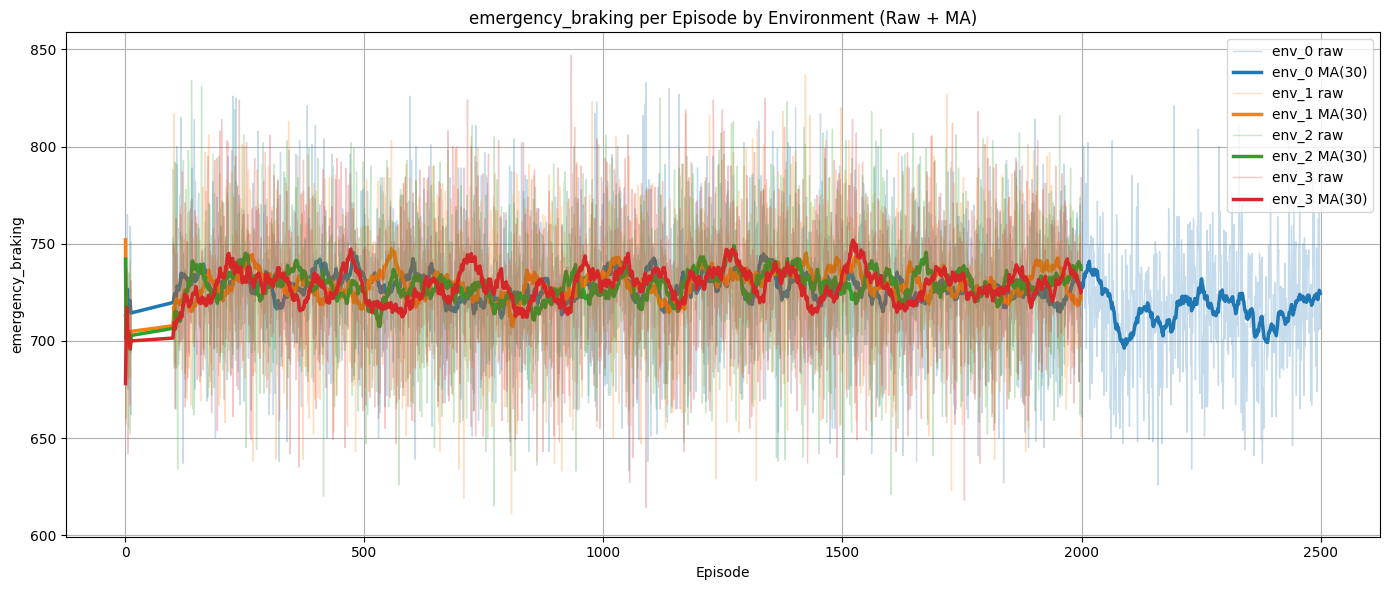

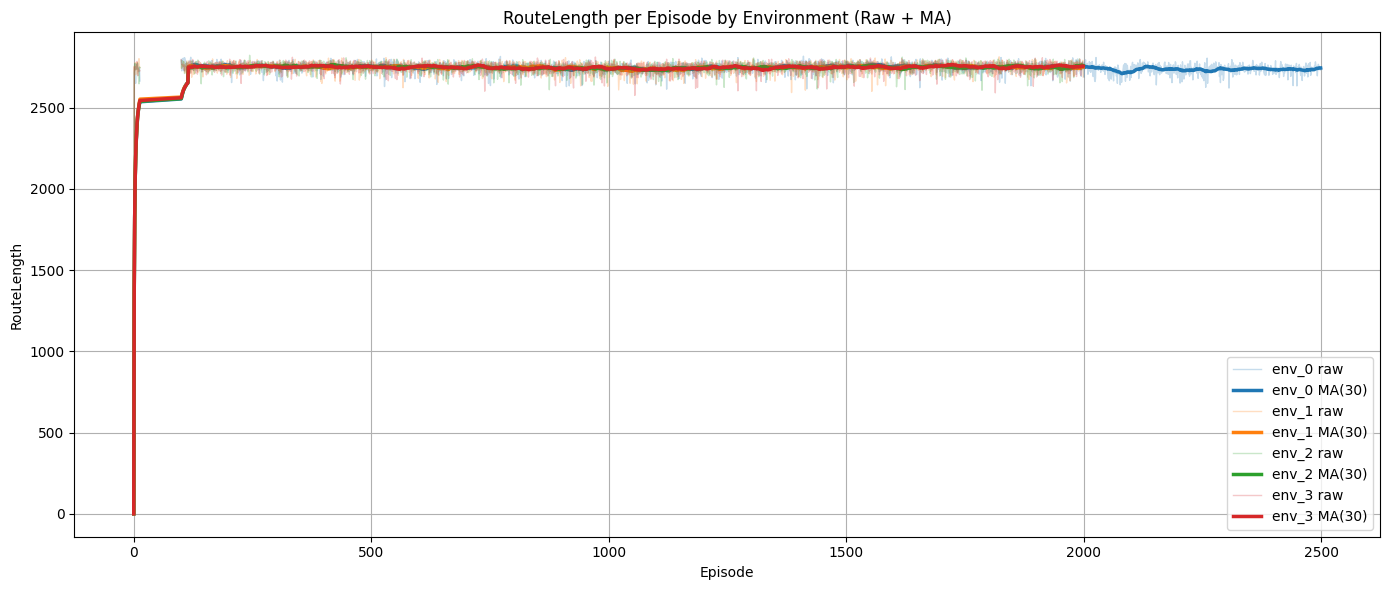

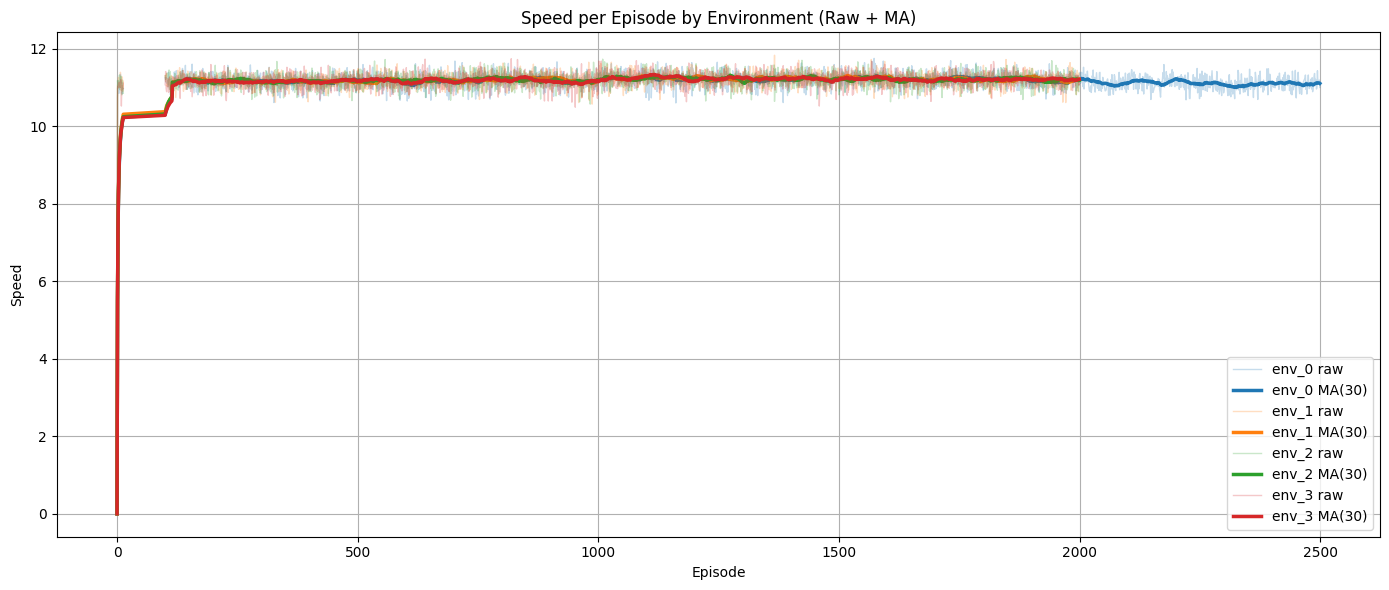

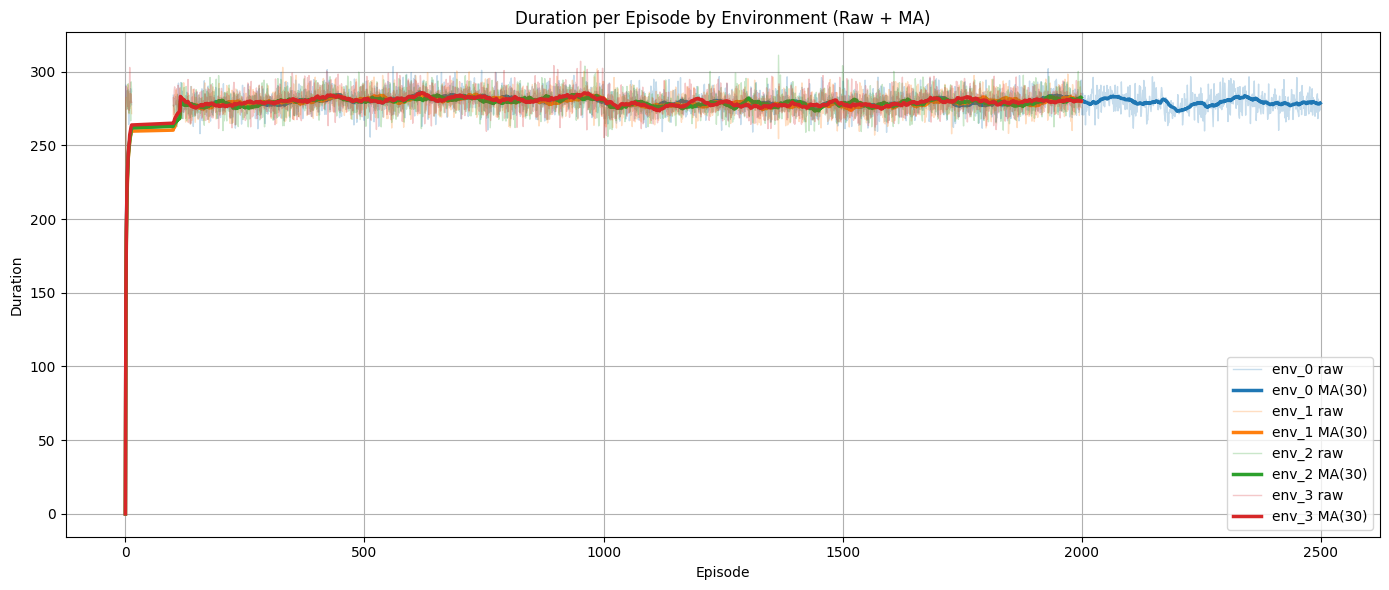

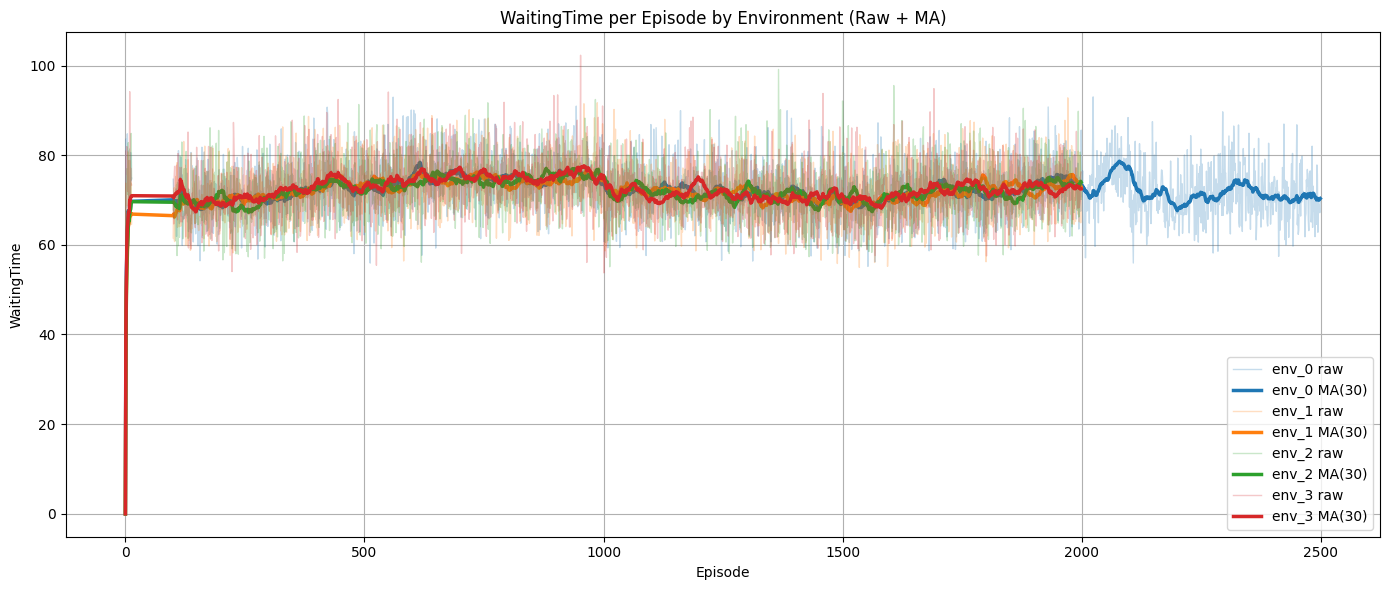

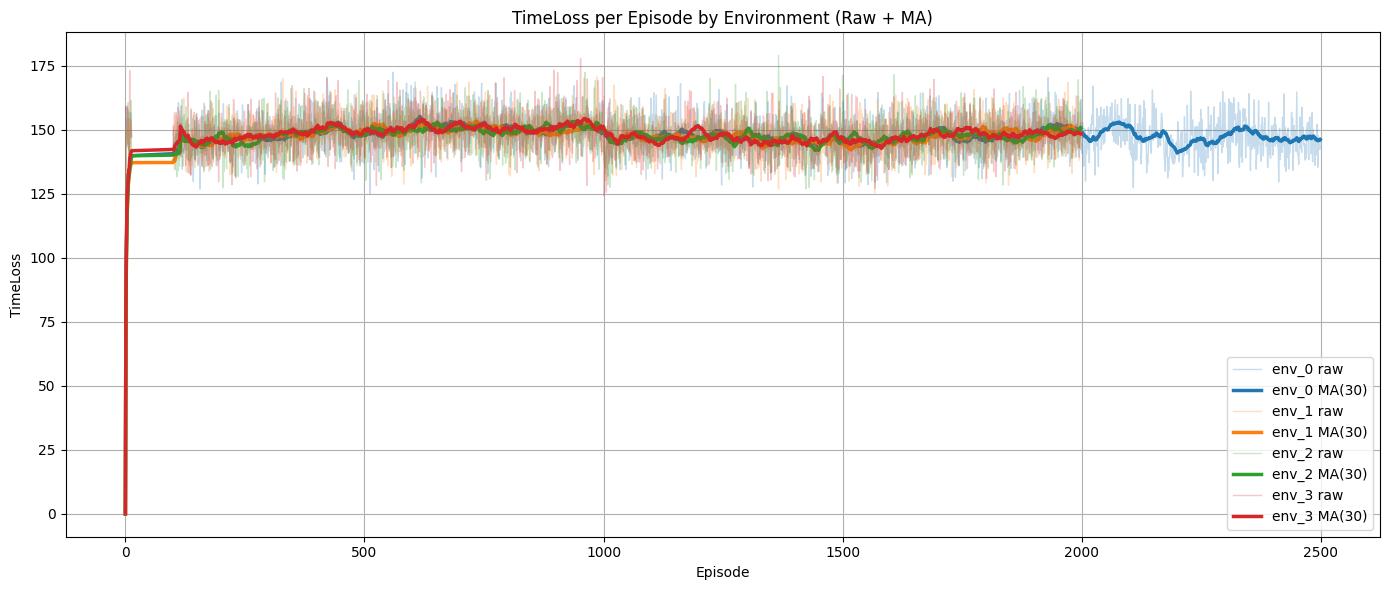

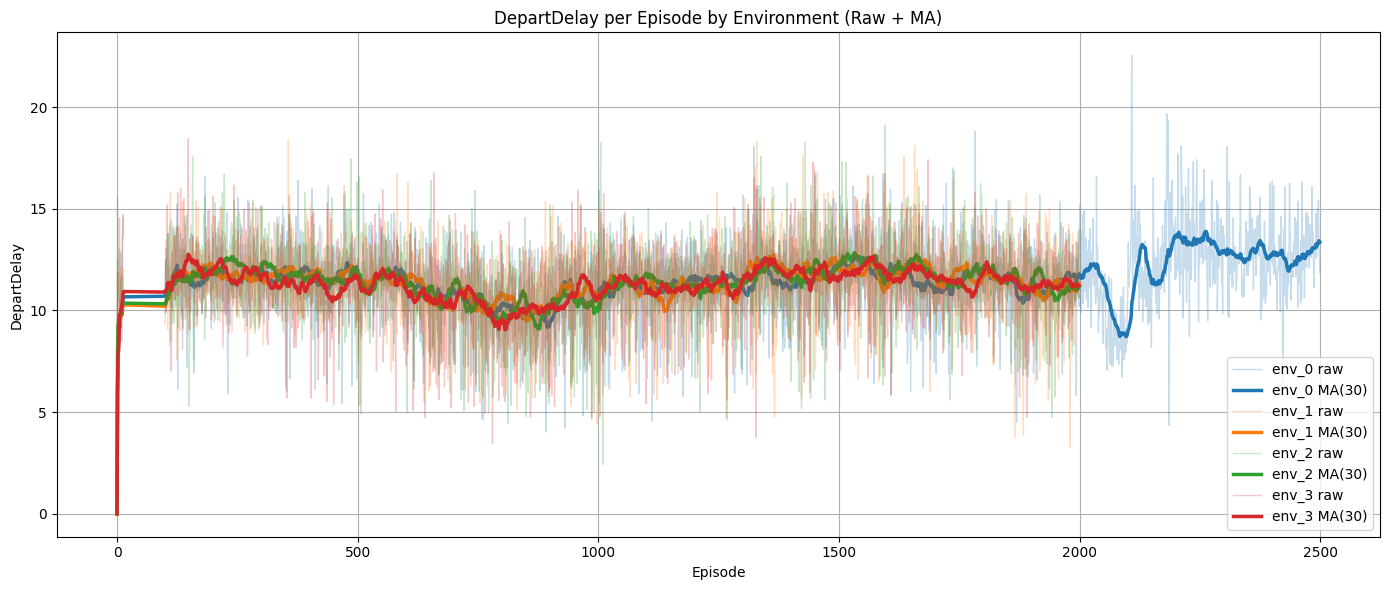

In [40]:
colors = plt.cm.tab10.colors

# pick numeric columns to plot (excluding env and episode)
cols = [c for c in dqn_logs.columns if c not in ["environment", "episode"]]

for col in cols:
    plt.figure(figsize=(14, 6))
    for i, env in enumerate(dqn_logs["environment"].unique()):
        df_env = dqn_logs[dqn_logs["environment"] == env].sort_values("episode")
        x = df_env["episode"]
        y = df_env[col]
        color = colors[i % len(colors)]

        # raw line (transparent)
        plt.plot(x, y, color=color, alpha=0.25, linewidth=1, label=f"{env} raw")

        # moving average (fully visible)
        y_ma = y.rolling(window=30, min_periods=1).mean()
        plt.plot(x, y_ma, color=color, linewidth=2.5, label=f"{env} MA(30)")

    plt.xlabel("Episode")
    plt.ylabel(col)
    plt.title(f"{col} per Episode by Environment (Raw + MA)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
